# 05 — Supervised prediction of molecular subtype

This notebook evaluates whether TCGA-BRCA molecular subtype annotations can be predicted from global gene expression profiles.

Unlike unsupervised clustering, this analysis uses known subtype labels during model training. The goal is to assess how much subtype-related signal is present in the transcriptomic data and which subtype distinctions are easier or harder to learn.

In [8]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

pd.set_option("display.max_columns", 100)
sns.set_context("notebook")

In [9]:
PROJECT_ROOT = Path("..").resolve()

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

expression_path = PROCESSED_DIR / "expression_rsem_samples_by_gene.tsv"
metadata_path = PROCESSED_DIR / "clinical_marker_analysis_table.tsv"

print("Expression exists:", expression_path.exists())
print("Metadata exists:", metadata_path.exists())

Expression exists: True
Metadata exists: True


In [10]:
expression = pd.read_csv(expression_path, sep="\t")
metadata = pd.read_csv(metadata_path, sep="\t")

print("expression:", expression.shape)
print("metadata:", metadata.shape)

display(expression.head())
display(metadata.head())

expression: (1082, 20514)
metadata: (1082, 72)


,SAMPLE_ID_ORIGINAL,SAMPLE_ID_15,PATIENT_ID_12,A1BG,A1CF,A2BP1,A2LD1,A2M,A2M-AS1,A2ML1,A4GALT,A4GNT,AAA1,AAAS,AACS,AACSL,AADAC,AADACL2,AADACL3,AADACL4,AADACP1,AADAT,AAGAB,AAK1,AAMP,AANAT,AARS,AARS2,AARSD1,AASDH,AASDHPPT,AASS,AATBC,AATF,AATK,ABAT,ABCA1,ABCA10,ABCA11P,ABCA12,ABCA13,ABCA17P,ABCA2,ABCA3,ABCA4,ABCA5,ABCA6,ABCA7,ABCA8,ABCA9,...,ZNRF2,ZNRF2P1,ZNRF3,ZNRF4,ZP1,ZP2,ZP3,ZP4,ZPBP,ZPBP2,ZPLD1,ZRANB1,ZRANB2,ZRANB3,ZRSR2,ZSCAN1,ZSCAN10,ZSCAN12,ZSCAN12P1,ZSCAN16,ZSCAN18,ZSCAN2,ZSCAN20,ZSCAN21,ZSCAN22,ZSCAN23,ZSCAN29,ZSCAN4,ZSCAN5A,ZSCAN5B,ZSWIM1,ZSWIM2,ZSWIM3,ZSWIM4,ZSWIM5,ZSWIM6,ZSWIM7,ZUFSP,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,psiTPTE22
0,TCGA-3C-AAAU-01,TCGA-3C-AAAU-01,TCGA-3C-AAAU,197.090,0.0000,0.0000,102.9630,5798.37,32.2187,1.3786,68.2424,8.6165,0.3447,649.337,1087.400,1.3786,0.0000,0.0,0.0000,0.0,0.0000,5.5145,1300.40,517.333,2053.13,0.3447,4409.56,689.897,466.668,277.450,808.914,45.8396,111.6690,1518.91,619.5930,620.731,288.462,16.2334,79.1509,321.2220,0.0000,17.9223,4507.450,5470.770,3.7912,795.093,23.0921,596.9490,58.5920,37.5678,...,414.969,76.1696,741.706,0.0,3.7912,0.0000,411.791,0.0000,1.034,0.3447,53.7668,879.225,2504.080,72.0337,421.862,0.3447,2.7573,141.6550,128.1790,225.062,132.349,582.473,158.8880,253.510,300.887,38.2571,960.220,0.3447,32.3979,1.0340,431.513,0.3447,180.2570,489.416,454.9500,621.764,194.108,89.956,430.824,415.824,931.957,129.5920,1007.780,1658.500,258.4940,1208.370,3507.25,1894.930,1180.460,1.7233
1,TCGA-3C-AALI-01,TCGA-3C-AALI-01,TCGA-3C-AALI,237.384,0.0000,0.0000,70.8646,7571.98,29.9782,4.3502,157.6940,0.5438,0.0000,887.983,836.324,35.3453,1.0875,0.0,0.0000,0.0,0.0000,24.4698,3541.05,848.287,2979.88,2.1751,4570.96,472.501,418.706,184.339,678.630,71.7781,13.5943,7649.27,107.6670,240.348,421.930,17.9445,96.0903,678.6300,1.6313,70.6906,2330.070,2656.880,45.1332,388.798,25.0136,763.4580,20.1196,46.2208,...,841.218,39.6955,373.573,0.0,30.4513,4.3502,439.222,0.5438,0.000,2.1751,3.2626,566.068,627.656,62.5340,349.647,18.4883,0.0000,91.8978,58.2164,174.551,1549.760,236.542,27.7325,698.521,197.390,7.0691,588.363,0.0000,127.7870,4.3502,507.341,0.0000,139.2060,475.802,113.6490,242.523,217.134,105.492,340.402,1161.330,965.198,59.8151,448.613,1343.120,198.4770,603.589,5504.62,1318.650,406.743,926.5910
2,TCGA-3C-AALJ-01,TCGA-3C-AALJ-01,TCGA-3C-AALJ,423.237,0.9066,0.0000,161.2600,8840.40,17.2620,0.0000,573.8890,0.0000,0.0000,723.481,1533.090,2.7199,0.9066,0.0,1.8132,0.0,1.8132,53.4905,1360.83,568.450,2291.93,1.8132,2556.66,439.710,390.752,190.390,779.692,76.1559,20.8522,2097.91,145.0590,375.340,689.882,27.1985,156.0200,0.0000,0.9066,12.6927,3208.520,1514.050,1.8132,559.384,81.5956,383.5000,52.5839,54.3971,...,266.546,38.9846,257.480,0.0,2.7199,0.0000,334.506,0.0000,0.000,0.0000,117.8600,1125.110,1951.210,35.3581,470.535,112.4210,0.0000,99.7280,38.2684,110.607,2225.750,268.359,52.5839,282.865,138.713,46.2375,514.053,0.0000,62.5567,0.0000,352.675,0.0000,81.5956,485.947,180.4170,506.800,164.234,235.721,304.624,305.422,2531.280,35.3581,533.998,768.812,331.8220,532.185,5458.75,942.883,509.519,35.3581
3,TCGA-3C-AALK-01,TCGA-3C-AALK-01,TCGA-3C-AALK,191.018,0.0000,0.0000,62.5072,10960.20,17.8527,1.6549,506.4130,0.0000,0.0000,776.996,858.088,0.0000,2.8962,0.0,0.0000,0.0,1.2412,57.0956,1683.49,727.762,2762.52,0.4137,2122.88,431.936,493.587,196.525,665.288,183.2850,38.8912,1915.18,119.9840,1721.560,749.264,23.5830,137.3230,1430.7000,2.4824,9.1022,1375.260,968.556,73.2313,412.081,78.1961,465.8670,213.4880,70.3351,...,632.602,50.0621,330.161,0.0,1.2412,1.6549,127.017,0.4137,0.000,0.0000,9.1022,780.306,1195.830,61.2329,364.501,6.2060,0.8275,211.8330,33.4506,163.012,1276.380,304.923,36.8225,300.625,122.466,26.4791,409.185,0.4137,57.5093,0.8275,286.305,0.0000,67.0252,626.396,107.5710,340.505,196.136,148.531,314.026,394.506,668.597,55.0269,437.733,863.881,175.4240,607.365,5691.35,781.134,700.869,66.6115
4,TCGA-4H-AAAK-01,TCGA-4H-AAAK-01,TCGA-4H-AAAK,268.881,0.4255,3.8298,154.3700,9585.44,31.5787

,PATIENT_ID_sample,SAMPLE_ID,ONCOTREE_CODE,CANCER_TYPE,CANCER_TYPE_DETAILED,TUMOR_TYPE,GRADE,TISSUE_PROSPECTIVE_COLLECTION_INDICATOR,TISSUE_RETROSPECTIVE_COLLECTION_INDICATOR,TISSUE_SOURCE_SITE_CODE,TUMOR_TISSUE_SITE,ANEUPLOIDY_SCORE,SAMPLE_TYPE,MSI_SCORE_MANTIS,MSI_SENSOR_SCORE,SOMATIC_STATUS,TMB_NONSYNONYMOUS,TISSUE_SOURCE_SITE,TBL_SCORE,SAMPLE_ID_ORIGINAL_x,SAMPLE_ID_15,PATIENT_ID_12,PATIENT_ID_patient,SUBTYPE,CANCER_TYPE_ACRONYM,OTHER_PATIENT_ID,AGE,SEX,AJCC_PATHOLOGIC_TUMOR_STAGE,AJCC_STAGING_EDITION,DAYS_LAST_FOLLOWUP,DAYS_TO_BIRTH,DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS,ETHNICITY,FORM_COMPLETION_DATE,HISTORY_NEOADJUVANT_TRTYN,ICD_10,ICD_O_3_HISTOLOGY,ICD_O_3_SITE,INFORMED_CONSENT_VERIFIED,NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT,PATH_M_STAGE,PATH_N_STAGE,PATH_T_STAGE,PERSON_NEOPLASM_CANCER_STATUS,PRIMARY_LYMPH_NODE_PRESENTATION_ASSESSMENT,PRIOR_DX,RACE,RADIATION_THERAPY,WEIGHT,IN_PANCANPATHWAYS_FREEZE,OS_STATUS,OS_MONTHS,DSS_STATUS,DSS_MONTHS,DFS_STATUS,DFS_MONTHS,PFS_STATUS,PFS_MONTHS,GENETIC_ANCESTRY_LABEL,SAMPLE_ID_ORIGINAL_y,SAMPLE_ID_ORIGINAL,ESR1,PGR,ERBB2,MKI67,FOXA1,GATA3,TP53,PIK3CA,BRCA1,BRCA2
0,TCGA-3C-AAAU,TCGA-3C-AAAU-01,ILC,Breast Cancer,Breast Invasive Lobular Carcinoma,Infiltrating Lobular Carcinoma,NaN,No,Yes,3C,Breast,19.0,Primary,0.3319,0.55,Matched,0.800000,Columbia University,205.0,TCGA-3C-AAAU-01,TCGA-3C-AAAU-01,TCGA-3C-AAAU,TCGA-3C-AAAU,BRCA_LumA,BRCA,6E7D5EC6-A469-467C-B748-237353C23416,55,Female,STAGE X,6TH,4047.0,-20211.0,0,Not Hispanic Or Latino,1/13/14,No,C50.9,8520/3,C50.9,Yes,No,MX,NX,TX,With Tumor,Yes,No,White,No,NaN,Yes,0:LIVING,133.050597,0:ALIVE OR DEAD TUMOR FREE,133.050597,1:Recurred/Progressed,59.440444,1:PROGRESSION,59.440444,EUR,TCGA-3C-AAAU-01,TCGA-3C-AAAU-01,3457.9600,2273.2700,7113.41,2582.870,5448.37,14337.50,1385.530,487.003,831.317,178.878
1,TCGA-3C-AALI,TCGA-3C-AALI-01,IDC,Breast Cancer,Breast Invasive Ductal Carcinoma,Infiltrating Ductal Carcinoma,NaN,No,Yes,3C,Breast,22.0,Primary,0.3449,0.74,Matched,15.266667,Columbia University,190.0,TCGA-3C-AALI-01,TCGA-3C-AALI-01,TCGA-3C-AALI,TCGA-3C-AALI,BRCA_Her2,BRCA,55262FCB-1B01-4480-B322-36570430C917,50,Female,STAGE IIB,6TH,4005.0,-18538.0,0,Not Hispanic Or Latino,7/28/14,No,C50.9,8500/3,C50.9,Yes,No,M0,N1A,T2,Tumor Free,Yes,No,Black or African American,Yes,NaN,Yes,0:LIVING,131.669790,0:ALIVE OR DEAD TUMOR FREE,131.669790,0:DiseaseFree,131.669790,0:CENSORED,131.669790,AFR,TCGA-3C-AALI-01,TCGA-3C-AALI-01,68.5155,27.1887,194625.00,2285.480,6049.48,7437.74,414.356,321.914,389.886,153.888
2,TCGA-3C-AALJ,TCGA-3C-AALJ-01,IDC,Breast Cancer,Breast Invasive Ductal Carcinoma,Infiltrating Ductal Carcinoma,NaN,No,Yes,3C,Breast,13.0,Primary,0.3266,0.31,Matched,0.933333,Columbia University,365.0,TCGA-3C-AALJ-01,TCGA-3C-AALJ-01,TCGA-3C-AALJ,TCGA-3C-AALJ,BRCA_LumB,BRCA,427D0648-3F77-4FFC-B52C-89855426D647,62,Female,STAGE IIB,7TH,1474.0,-22848.0,0,Not Hispanic Or Latino,7/28/14,No,C50.9,8500/3,C50.9,Yes,No,M0,N1A,T2,Tumor Free,Yes,No,Black or African American,No,NaN,Yes,0:LIVING,48.459743,0:ALIVE OR DEAD TUMOR FREE,48.459743,0:DiseaseFree,48.459743,0:CENSORED,48.459743,AFR_ADMIX,TCGA-3C-AALJ-01,TCGA-3C-AALJ-01,7482.3200,473.8350,11070.70,949.229,4620.13,10252.90,1289.210,216.682,200.363,151.405
3,TCGA-3C-AALK,TCGA-3C-AALK-01,IDC,Breast Cancer,Breast Invasive Ductal Carcinoma,Infiltrating Ductal Carcinoma,NaN,No,Yes,3C,Breast,4.0,Primary,0.3218,0.03,Matched,1.500000,Columbia University,25.0,TCGA-3C-AALK-01,TCGA-3C-AALK-01,TCGA-3C-AALK,TCGA-3C-AALK,BRCA_LumA,BRCA,C31900A4-5DCD-4022-97AC-638E86E889E4,52,Female,STAGE IA,7TH,1448.0,-19074.0,0,Not Hispanic Or Latino,7/28/14,No,C50.9,8500/3,C50.9,Yes,No,M0,N0 (I+),T1C,Tumor Free,Yes,No,Black or African American,No,NaN,Yes,0:LIVING,47.604958,0:ALIVE OR DEAD TUMOR FREE,47.604958,NaN,NaN,0:CENSORED,47.604958,AFR,TCGA-3C-AALK-01,TCGA-3C-AALK-01,2485.3100,2236.4600,36022.80,1139.430,7352.09,8761.69,1418.290,326.024,148.118,102.193
4,TCGA-4H-AAAK,TCGA-4H-AAAK-01,ILC,Breast Cancer,Breast Invasive Lobular Carcinoma,

In [11]:
id_cols = ["SAMPLE_ID_15", "PATIENT_ID_12"]

metadata = metadata.drop_duplicates(subset=id_cols).copy()

df = expression.merge(
    metadata[id_cols + ["SUBTYPE"]],
    on=id_cols,
    how="inner"
)

df = df[df["SUBTYPE"].notna()].copy()

print("Merged table with subtype:", df.shape)
display(df["SUBTYPE"].value_counts())

Merged table with subtype: (981, 20515)


SUBTYPE
BRCA_LumA      499
BRCA_LumB      197
BRCA_Basal     171
BRCA_Her2       78
BRCA_Normal     36
Name: count, dtype: int64

In [12]:
non_gene_cols = [
    "SAMPLE_ID",
    "SAMPLE_ID_ORIGINAL",
    "SAMPLE_ID_15",
    "PATIENT_ID_12",
    "SUBTYPE",
]

gene_cols = [
    col for col in expression.columns
    if col not in non_gene_cols
]

X_raw = df[gene_cols].apply(pd.to_numeric, errors="coerce")

# Remove genes with too many missing values
missing_fraction = X_raw.isna().mean(axis=0)
genes_keep = missing_fraction[missing_fraction < 0.05].index.tolist()

X_raw = X_raw[genes_keep]
X_raw = X_raw.fillna(X_raw.median(axis=0))

# log2 transform
X = np.log2(X_raw + 1)

y = df["SUBTYPE"].copy()

print("X:", X.shape)
print("y:", y.shape)
display(y.value_counts())

X: (981, 20511)
y: (981,)


SUBTYPE
BRCA_LumA      499
BRCA_LumB      197
BRCA_Basal     171
BRCA_Her2       78
BRCA_Normal     36
Name: count, dtype: int64

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

print("\nTrain subtype distribution:")
display(y_train.value_counts())

print("\nTest subtype distribution:")
display(y_test.value_counts())

Train: (735, 20511)
Test: (246, 20511)

Train subtype distribution:


SUBTYPE
BRCA_LumA      374
BRCA_LumB      148
BRCA_Basal     128
BRCA_Her2       58
BRCA_Normal     27
Name: count, dtype: int64


Test subtype distribution:


SUBTYPE
BRCA_LumA      125
BRCA_LumB       49
BRCA_Basal      43
BRCA_Her2       20
BRCA_Normal      9
Name: count, dtype: int64

SelectKBest → selecciona genes informativos
StandardScaler → escala expresión
LogisticRegression → clasificador lineal

In [14]:
model = Pipeline(
    steps=[
        ("feature_selection", SelectKBest(score_func=f_classif, k=1000)),
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                solver="lbfgs",
            ),
        ),
    ]
)

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_selection', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function f_c...t 0x122caa480>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",1000
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect 

In [15]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "balanced_accuracy"],
    return_train_score=True,
)

cv_summary = pd.DataFrame(cv_results)

display(cv_summary)

cv_metrics = cv_summary.agg(["mean", "std"]).T
display(cv_metrics)

cv_metrics.to_csv(TABLES_DIR / "subtype_prediction_cv_metrics.csv")

/Users/rubensiok/tcga-brca-translational-stratification/.venv/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  596  1592  3546  4363  4399  4402  4403  4404  4686  4687  4688  4851
  4853  4855  4858  4859  5325  5327  6079  6130  7728  7729  7730  7731
  9378  9385  9388  9393  9394  9395  9399  9400  9404  9534 11525 11801
 12411 13383 13859 14026 14027 14028 14029 14086 14637 14638 14639 14640
 14641 14642 14643 14644 14645 15026 15028 15029 15192 15339 16487 16488
 16489 16491 16492 16494 16498 16499 16527 16556 16559 16599 16619 16620
 16621 16622 16623 16624 16625 16626 16627 16628 16629 16630 16631 16632
 16633 16634 16635 16636 16637 16638 16639 16640 16641 16642 16643 16644
 16645 16646 16647 16648 16649 16650 16651 16652 16653 16654 16655 16656
 16657 16658 16659 16660 16661 16662 16663 16664 16665 16666 16667 16668
 16669 16671 16672 16673 16674 16675 16676 16677 16679 16680 16681 16682
 16683 16684 16685 16686 166

,fit_time,score_time,test_accuracy,train_accuracy,test_balanced_accuracy,train_balanced_accuracy
0,1.302855,0.179540,0.925170,1.0,0.877277,1.0
1,0.865192,0.409305,0.857143,1.0,0.833333,1.0
2,0.845406,0.163194,0.891156,1.0,0.880667,1.0
3,1.182871,0.170239,0.891156,1.0,0.854777,1.0
4,1.064930,0.162860,0.843537,1.0,0.744075,1.0


,mean,std
fit_time,1.052251,0.198621
score_time,0.217028,0.107700
test_accuracy,0.881633,0.032124
train_accuracy,1.000000,0.000000
test_balanced_accuracy,0.838026,0.055875
train_balanced_accuracy,1.000000,0.000000


In [16]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
test_balanced_accuracy = balanced_accuracy_score(y_test, y_pred)

print("Test accuracy:", round(test_accuracy, 3))
print("Test balanced accuracy:", round(test_balanced_accuracy, 3))

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).T
display(report_df)

report_df.to_csv(TABLES_DIR / "subtype_prediction_classification_report.csv")

/Users/rubensiok/tcga-brca-translational-stratification/.venv/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  596  3546  4363  4399  4402  4403  4404  4686  4687  4688  4851  4853
  4855  4859  5325  5327  6079  6130  7728  7729  7730  7731  9378  9385
  9388  9393  9395  9399  9400  9404  9534 11525 11801 12411 13383 13859
 14026 14027 14028 14029 14086 14637 14638 14639 14640 14641 14642 14643
 14644 14645 15026 15028 15029 15192 15339 16487 16488 16489 16491 16492
 16494 16498 16499 16527 16556 16559 16599 16619 16620 16621 16622 16623
 16624 16625 16626 16627 16628 16629 16630 16631 16632 16633 16634 16635
 16636 16637 16638 16639 16640 16641 16642 16643 16644 16645 16646 16647
 16648 16649 16650 16651 16652 16653 16654 16655 16656 16657 16658 16659
 16660 16661 16662 16663 16664 16665 16666 16667 16668 16669 16671 16672
 16673 16674 16675 16676 16677 16679 16680 16681 16682 16683 16684 16685
 16686 16687 16688 16689 166

Test accuracy: 0.939
Test balanced accuracy: 0.936


,precision,recall,f1-score,support
BRCA_Basal,1.000000,1.000000,1.000000,43.000000
BRCA_Her2,0.894737,0.850000,0.871795,20.000000
BRCA_LumA,0.959677,0.952000,0.955823,125.000000
BRCA_LumB,0.877551,0.877551,0.877551,49.000000
BRCA_Normal,0.818182,1.000000,0.900000,9.000000
accuracy,0.939024,0.939024,0.939024,0.939024
macro avg,0.910029,0.935910,0.921034,246.000000
weighted avg,0.939911,0.939024,0.939081,246.000000


,BRCA_Basal,BRCA_Her2,BRCA_LumA,BRCA_LumB,BRCA_Normal
BRCA_Basal,43,0,0,0,0
BRCA_Her2,0,17,1,1,1
BRCA_LumA,0,0,119,5,1
BRCA_LumB,0,2,4,43,0
BRCA_Normal,0,0,0,0,9


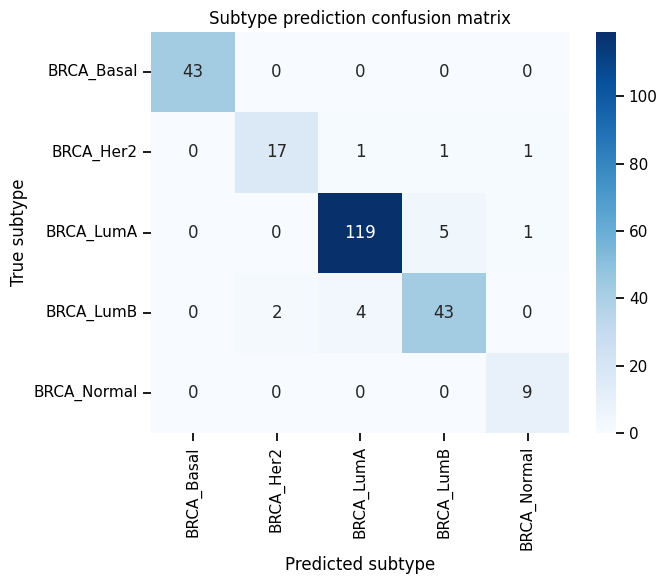

In [17]:
labels = sorted(y.unique())

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

cm_df = pd.DataFrame(
    cm,
    index=labels,
    columns=labels
)

display(cm_df)

cm_df.to_csv(TABLES_DIR / "subtype_prediction_confusion_matrix_counts.csv")

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Subtype prediction confusion matrix")
plt.xlabel("Predicted subtype")
plt.ylabel("True subtype")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "subtype_prediction_confusion_matrix_counts.png", dpi=300)
plt.show()

,BRCA_Basal,BRCA_Her2,BRCA_LumA,BRCA_LumB,BRCA_Normal
BRCA_Basal,1.0,0.000000,0.000000,0.000000,0.000
BRCA_Her2,0.0,0.850000,0.050000,0.050000,0.050
BRCA_LumA,0.0,0.000000,0.952000,0.040000,0.008
BRCA_LumB,0.0,0.040816,0.081633,0.877551,0.000
BRCA_Normal,0.0,0.000000,0.000000,0.000000,1.000


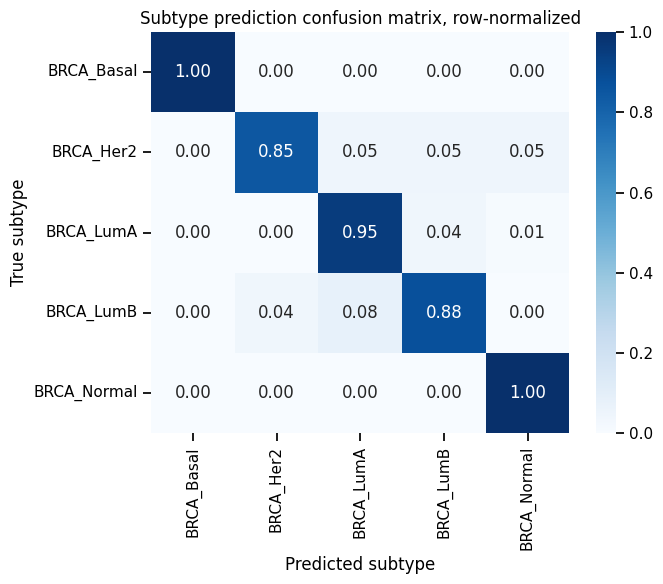

In [18]:
cm_norm = cm_df.div(cm_df.sum(axis=1), axis=0)

display(cm_norm)

cm_norm.to_csv(TABLES_DIR / "subtype_prediction_confusion_matrix_normalized.csv")

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1
)
plt.title("Subtype prediction confusion matrix, row-normalized")
plt.xlabel("Predicted subtype")
plt.ylabel("True subtype")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "subtype_prediction_confusion_matrix_normalized.png", dpi=300)
plt.show()

In [19]:
feature_selector = model.named_steps["feature_selection"]
classifier = model.named_steps["classifier"]

selected_mask = feature_selector.get_support()
selected_genes = X.columns[selected_mask]

print("Selected genes:", len(selected_genes))
print(selected_genes[:20].tolist())

Selected genes: 1000
['A2ML1', 'AAGAB', 'ABAT', 'ABCA13', 'ABCC11', 'ABCC8', 'ABCG1', 'ABLIM3', 'ABTB2', 'ACADSB', 'ACBD4', 'ACE2', 'ACOT4', 'ACOX2', 'ADAMTS15', 'ADCY9', 'AFAP1-AS1', 'AFF3', 'AGGF1', 'AGR2']


In [20]:
coef_df = pd.DataFrame(
    classifier.coef_,
    index=classifier.classes_,
    columns=selected_genes
)

display(coef_df.iloc[:, :10])

,A2ML1,AAGAB,ABAT,ABCA13,ABCC11,ABCC8,ABCG1,ABLIM3,ABTB2,ACADSB
BRCA_Basal,-0.012064,-0.019836,-0.004562,0.043158,-0.106504,-0.011231,-0.034845,-0.009459,0.028194,-0.002755
BRCA_Her2,-0.035236,0.017488,-0.022975,-0.005488,0.002244,0.007867,-0.015097,0.023272,-0.007321,-0.028622
BRCA_LumA,-0.010066,0.082015,-0.005857,-0.043348,0.012452,0.001888,0.154368,0.055377,0.015431,-0.020109
BRCA_LumB,0.021621,-0.081834,0.050906,-0.002026,0.001390,-0.034099,-0.095736,-0.077991,-0.088667,0.055526
BRCA_Normal,0.035744,0.002167,-0.017513,0.007704,0.090418,0.035575,-0.008691,0.008801,0.052364,-0.004040


In [21]:
top_model_genes = []

for subtype in coef_df.index:
    subtype_coef = coef_df.loc[subtype].sort_values(ascending=False)
    
    top_positive = subtype_coef.head(15).reset_index()
    top_positive.columns = ["gene", "coefficient"]
    top_positive["subtype"] = subtype
    top_positive["direction"] = "positive"
    
    top_negative = subtype_coef.tail(15).reset_index()
    top_negative.columns = ["gene", "coefficient"]
    top_negative["subtype"] = subtype
    top_negative["direction"] = "negative"
    
    top_model_genes.append(top_positive)
    top_model_genes.append(top_negative)

top_model_genes_df = pd.concat(top_model_genes, axis=0)

display(top_model_genes_df)

top_model_genes_df.to_csv(
    TABLES_DIR / "subtype_prediction_top_model_genes.csv",
    index=False
)

,gene,coefficient,subtype,direction
0,LIN28B,0.093522,BRCA_Basal,positive
1,SLC6A2,0.088500,BRCA_Basal,positive
2,KCNS1,0.087144,BRCA_Basal,positive
3,CXorf61,0.080726,BRCA_Basal,positive
4,AMY1A,0.079059,BRCA_Basal,positive
...,...,...,...,...
10,SRMS,-0.103521,BRCA_Normal,negative
11,TCAM1P,-0.104705,BRCA_Normal,negative
12,FAM72A,-0.107998,BRCA_Normal,negative
13,HMMR,-0.116516,BRCA_Normal,negative


Known BRCA genes selected by the model:
['ESR1', 'PGR', 'ERBB2', 'MKI67', 'FOXA1', 'GATA3']


,ESR1,PGR,ERBB2,MKI67,FOXA1,GATA3
BRCA_Basal,0.001431,-0.009716,-0.098629,-0.004880,-0.053071,-0.008674
BRCA_Her2,-0.115593,-0.041322,0.239298,0.061827,0.014372,-0.020812
BRCA_LumA,0.017617,0.173808,-0.048809,-0.023561,0.024040,0.029263
BRCA_LumB,0.099516,-0.118462,-0.140045,-0.024757,-0.009626,0.002858
BRCA_Normal,-0.002970,-0.004309,0.048186,-0.008629,0.024285,-0.002636


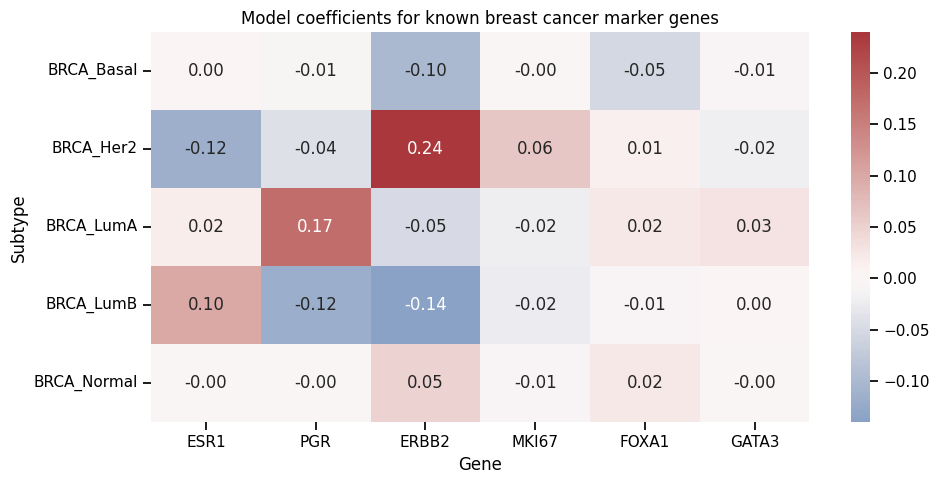

In [22]:
known_brca_genes = [
    "ESR1",
    "PGR",
    "ERBB2",
    "MKI67",
    "FOXA1",
    "GATA3",
    "KRT5",
    "KRT14",
    "KRT17",
    "EPCAM",
    "TP53",
    "PIK3CA",
    "BRCA1",
    "BRCA2",
]

known_selected = [
    gene for gene in known_brca_genes
    if gene in coef_df.columns
]

print("Known BRCA genes selected by the model:")
print(known_selected)

if known_selected:
    known_coef_df = coef_df[known_selected].copy()
    display(known_coef_df)

    known_coef_df.to_csv(
        TABLES_DIR / "subtype_prediction_known_gene_coefficients.csv"
    )

    plt.figure(figsize=(10, 5))
    sns.heatmap(
        known_coef_df,
        cmap="vlag",
        center=0,
        annot=True,
        fmt=".2f"
    )
    plt.title("Model coefficients for known breast cancer marker genes")
    plt.xlabel("Gene")
    plt.ylabel("Subtype")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "subtype_prediction_known_gene_coefficients.png", dpi=300)
    plt.show()
else:
    print("None of the known marker genes were selected among the top 1000 features.")

In [23]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate

dummy = DummyClassifier(strategy="most_frequent")

dummy_results = cross_validate(
    dummy,
    X_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "balanced_accuracy"]
)

pd.DataFrame(dummy_results).agg(["mean", "std"]).T

,mean,std
fit_time,0.602503,0.205045
score_time,0.001940,0.000154
test_accuracy,0.508844,0.003042
test_balanced_accuracy,0.200000,0.000000


## Preliminary interpretation

This supervised analysis asks whether molecular subtype annotations can be predicted from global gene expression profiles.

Unlike PCA or clustering, the model is trained using known subtype labels. Therefore, high predictive performance would indicate that subtype-related information is strongly encoded in the transcriptomic data.

The confusion matrix should be interpreted biologically:

- Basal-like tumours are expected to be among the easiest to classify because they are transcriptionally distinct.
- Luminal A and Luminal B may be more frequently confused because both are luminal subtypes and differ partly by proliferation-associated expression.
- HER2-enriched samples may overlap with Luminal B or other proliferative subtypes.
- Normal-like samples are retained as an annotated subtype, but interpretation should be cautious because this group is smaller and may reflect normal-like expression or tissue composition effects.

This analysis complements the previous notebooks:

1. Marker analysis checks known biology.
2. PCA/clustering explores unsupervised structure.
3. Differential expression identifies subtype-associated genes.
4. Supervised prediction quantifies how well expression profiles recover subtype labels.